Using CSV: ../datas/density_random_cli-1.csv


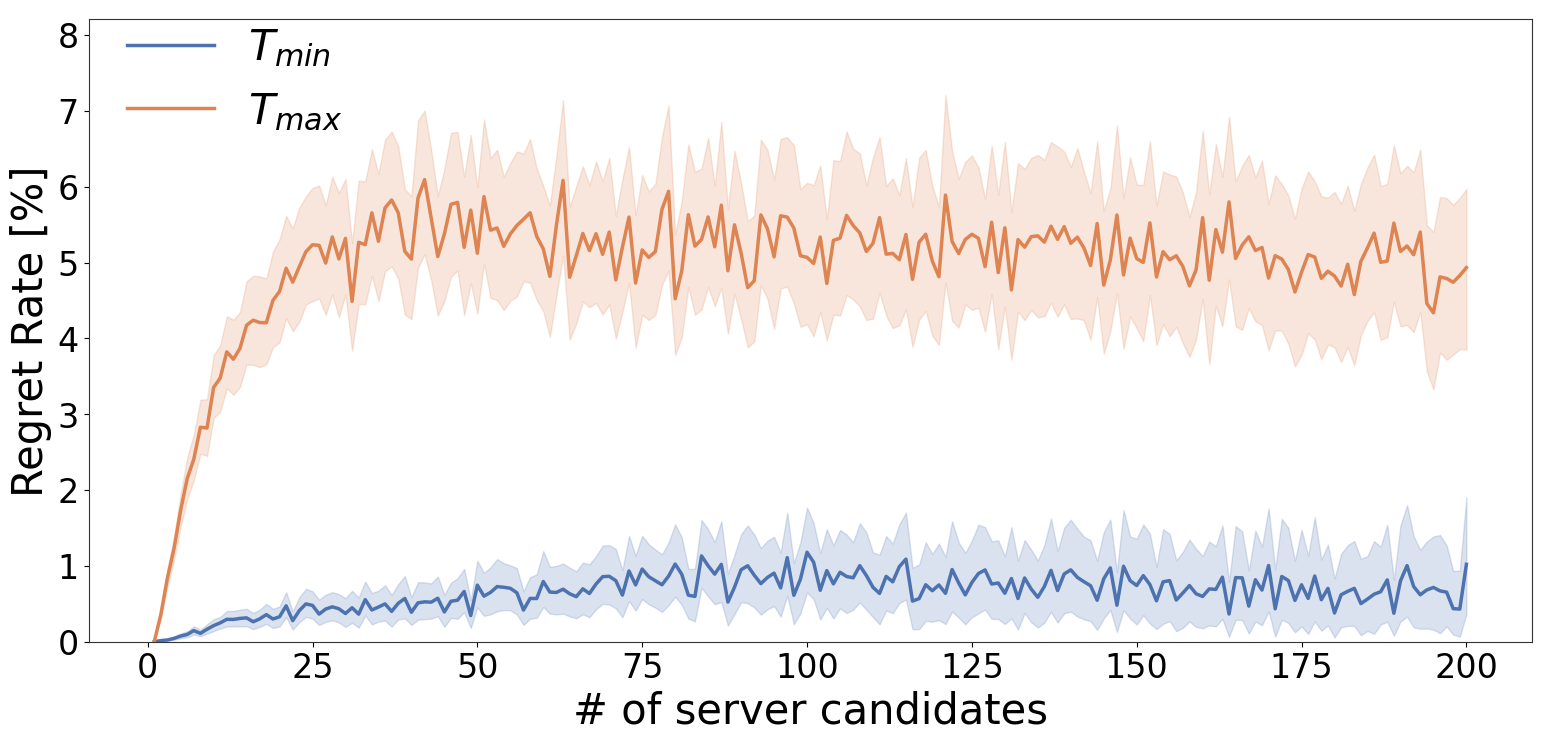

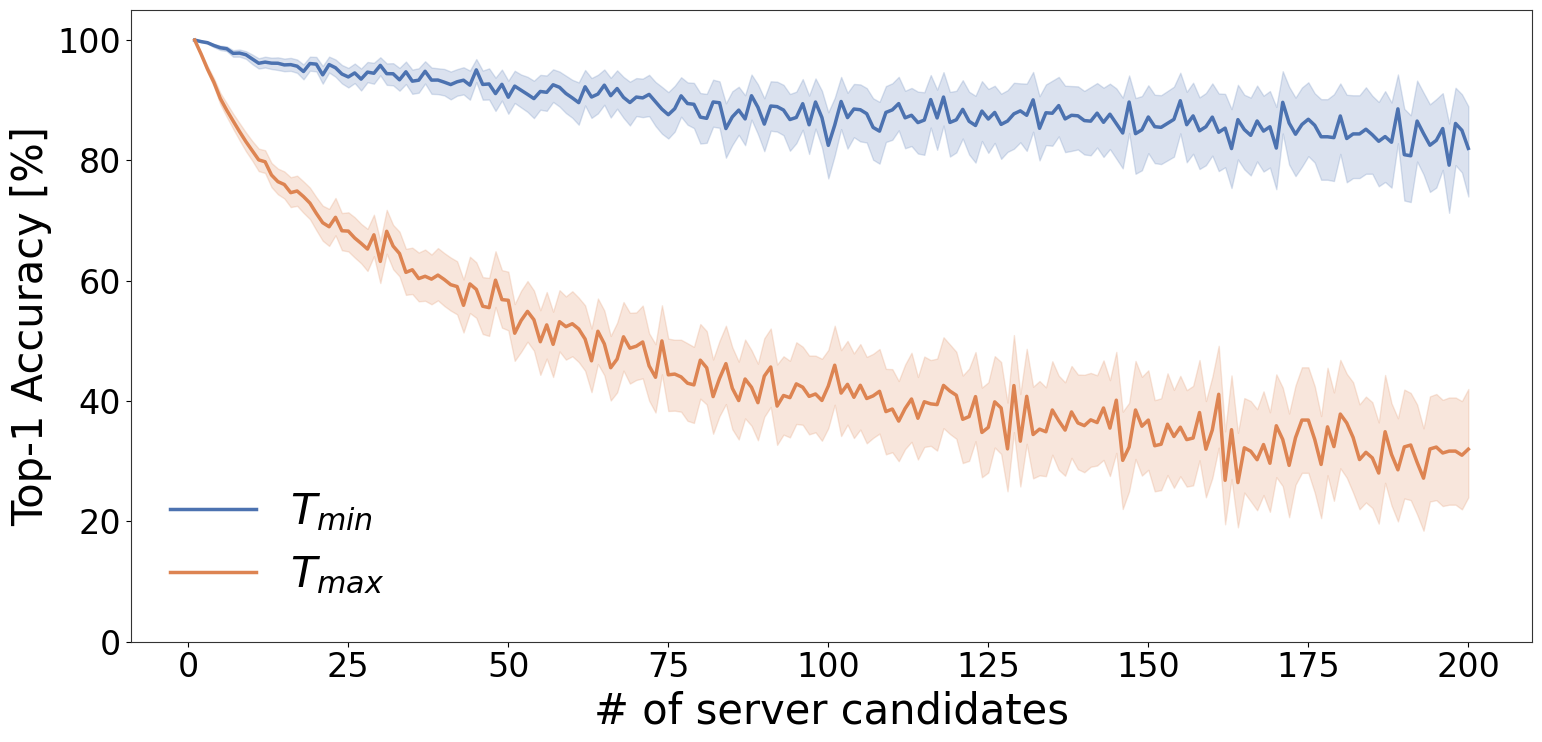

In [2]:
# Minimal visualization: CLI factor sweep (Regret & Top-1)
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 26,
    'axes.labelsize': 30,
    'axes.titlesize': 32,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 31,
})

# Bright clean look (grid off)
plt.rcParams.update({
    'axes.facecolor': '#FFFFFF',
    'figure.facecolor': '#FFFFFF',
    'axes.edgecolor': '#333333',
    'axes.grid': False,
    'grid.color': '#DDDDDD',
    'grid.alpha': 1.0,
    'grid.linewidth': 1.0,
    'grid.linestyle': '-',
})

# -------- helpers --------
def prepare_density_frame(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    # Ensure consistent ordering
    order_cols = [c for c in ['set_index','sample_index'] if c in df.columns]
    if order_cols:
        df = df.sort_values(order_cols).reset_index(drop=True)
    # numeric cols for calc
    num_cols = [c for c in ['shots','distance','entanglement_speed_factor','gate_speed_factor','zz_time'] if c in df.columns]
    for c in num_cols:
        df[c] = df[c].astype(float)
    # actual total from measurement
    df['zz_time_total_s'] = df['zz_time'] / 1e9
    # per-shot components
    if (df['entanglement_speed_factor'] == 0).any():
        raise ZeroDivisionError('entanglement_speed_factor must be non-zero.')
    if (df['gate_speed_factor'] == 0).any():
        raise ZeroDivisionError('gate_speed_factor must be non-zero.')
    # distance term uses 5 classical rounds (2.5 one-way) with ~2e8 m/s; here using 2e8 scale (5/2e8)
    df['t_distance_per_shot_s'] = 5.0 * df['distance'] / 200000.0
    df['t_entangle_per_shot_s'] = 5.0 / df['entanglement_speed_factor']
    df['t_gate_per_shot_s'] = 0.0165 / df['gate_speed_factor']
    per_cols = ['t_distance_per_shot_s','t_entangle_per_shot_s','t_gate_per_shot_s']
    df['L_value_per_shot_s'] = df[per_cols].max(axis=1)
    df['U_value_per_shot_s'] = df[per_cols].sum(axis=1)
    df['L_total_s'] = df['L_value_per_shot_s'] * df['shots']
    df['U_total_s'] = df['U_value_per_shot_s'] * df['shots']
    return df

def bootstrap_ci_mean(arr, n_boot=1500, seed=42):
    arr = np.asarray(arr, dtype=float)
    n = len(arr)
    if n == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    means = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        means[b] = arr[idx].mean()
    lo = float(np.percentile(means, 2.5)); hi=float(np.percentile(means,97.5))
    return float(arr.mean()), lo, hi

def summarize_regret_rate_bootstrap(df: pd.DataFrame, max_group_size: int, n_boot=1500, seed=42) -> pd.DataFrame:
    recs = []
    for size in range(1, max_group_size+1):
        total = len(df)//size
        if total==0:
            continue
        trimmed = df.iloc[: total*size].copy()
        trimmed['group_id'] = np.arange(len(trimmed)) // size
        Ls, Us = [], []
        for _, g in trimmed.groupby('group_id'):
            a = g.loc[g['zz_time_total_s'].idxmin()]
            L = g.loc[g['L_total_s'].idxmin()]
            U = g.loc[g['U_total_s'].idxmin()]
            at = float(a['zz_time_total_s'])
            if at>0:
                Ls.append(abs(float(L['zz_time_total_s'])-at)/at*100.0)
                Us.append(abs(float(U['zz_time_total_s'])-at)/at*100.0)
        Lm,Llo,Lhi = bootstrap_ci_mean(Ls, n_boot=n_boot, seed=seed+size*101+1)
        Um,Ulo,Uhi = bootstrap_ci_mean(Us, n_boot=n_boot, seed=seed+size*101+2)
        recs.append({'group_size':size,'L_mean':Lm,'L_lo':Llo,'L_hi':Lhi,'U_mean':Um,'U_lo':Ulo,'U_hi':Uhi})
    return pd.DataFrame.from_records(recs)

def summarize_top1_bootstrap(df: pd.DataFrame, max_group_size: int, n_boot=1500, seed=42) -> pd.DataFrame:
    recs=[]
    for size in range(1, max_group_size+1):
        total=len(df)//size
        if total==0: continue
        trimmed=df.iloc[: total*size].copy()
        trimmed['group_id']=np.arange(len(trimmed))//size
        Lhits, Uhits = [], []
        for _, g in trimmed.groupby('group_id'):
            ia=g['zz_time_total_s'].idxmin(); iL=g['L_total_s'].idxmin(); iU=g['U_total_s'].idxmin()
            Lhits.append(float(g.loc[iL,'sample_index']==g.loc[ia,'sample_index']))
            Uhits.append(float(g.loc[iU,'sample_index']==g.loc[ia,'sample_index']))
        mL,loL,hiL = bootstrap_ci_mean(Lhits, n_boot=n_boot, seed=seed+size*101+3)
        mU,loU,hiU = bootstrap_ci_mean(Uhits, n_boot=n_boot, seed=seed+size*101+4)
        recs.append({'group_size':size,'L_mean_pct':mL*100.0,'L_lo_pct':loL*100.0,'L_hi_pct':hiL*100.0,
                     'U_mean_pct':mU*100.0,'U_lo_pct':loU*100.0,'U_hi_pct':hiU*100.0})
    return pd.DataFrame.from_records(recs)

def _fmt_tag(v: float) -> str:
    s=("%g"%v).replace('.', '_')
    return s.replace('-', 'm')

def _find_csv(tag: str):
    cands = [
        Path('..')/'datas'/f'density_random_cli-{tag}.csv',
        Path('data')/f'density_random_cli-{tag}.csv',
        Path('sim')/'src'/'data'/f'density_random_cli-{tag}.csv',
        Path('..').parent/'pb-vqe2'/'sim'/'src'/'data'/f'density_random_cli-{tag}.csv',
    ]
    for c in cands:
        if c.exists(): return c
    return None

# -------- run --------
FACTORS=[1]
MAX_GROUP_SIZE=200
for f in FACTORS:
    tag=_fmt_tag(f)
    csv_path=_find_csv(tag)
    if not csv_path:
        print(f'[WARN] CSV for cli factor {f} (tag={tag}) not found in known locations.')
        continue
    print('Using CSV:', csv_path)
    df=prepare_density_frame(csv_path)
    rr_ci=summarize_regret_rate_bootstrap(df, MAX_GROUP_SIZE, n_boot=1500, seed=42)
    t1_ci=summarize_top1_bootstrap(df, MAX_GROUP_SIZE, n_boot=1500, seed=42)
    # Regret plot
    fig, ax = plt.subplots(figsize=(16, 8))
    x = rr_ci['group_size']
    ax.plot(x, rr_ci['L_mean'], label=r'$T_{min}$', color='#4C72B0', linewidth=2.5)
    ax.fill_between(x, rr_ci['L_lo'], rr_ci['L_hi'], color='#4C72B0', alpha=0.2)
    ax.plot(x, rr_ci['U_mean'], label=r'$T_{max}$', color='#DD8452', linewidth=2.5)
    ax.fill_between(x, rr_ci['U_lo'], rr_ci['U_hi'], color='#DD8452', alpha=0.2)
    ax.set_xlabel('# of server candidates')
    ax.set_ylabel('Regret Rate [%]')
    ymax=float(max(rr_ci['L_hi'].max(), rr_ci['U_hi'].max())); ax.set_ylim(0, ymax+1.0)
    plt.grid(False); ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0, 1.05))
    plt.tight_layout(); plt.show()
    # Top-1 plot
    fig, ax = plt.subplots(figsize=(16, 8))
    x = t1_ci['group_size']
    ax.plot(x, t1_ci['L_mean_pct'], label=r'$T_{min}$', color='#4C72B0', linewidth=2.5)
    ax.fill_between(x, t1_ci['L_lo_pct'], t1_ci['L_hi_pct'], color='#4C72B0', alpha=0.2)
    ax.plot(x, t1_ci['U_mean_pct'], label=r'$T_{max}$', color='#DD8452', linewidth=2.5)
    ax.fill_between(x, t1_ci['U_lo_pct'], t1_ci['U_hi_pct'], color='#DD8452', alpha=0.2)
    ax.set_xlabel('# of server candidates')
    ax.set_ylabel('Top-1 Accuracy [%]')
    ax.set_ylim(0, 105)
    plt.grid(False); ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0, 0.3))
    plt.tight_layout(); plt.show()


